# Cellpose-derived corridor processing, corridor-only schematic

This notebook uses the Cellpose flow TIFF as the geometry source.

Panel C now displays only the horizontal corridor support represented by the measured first-to-last accessible-pixel span at each x-position. Every accessible pixel that is ignored for this corridor representation is shown in black. The underlying width measurements and exported profiles are unchanged.


In [1]:
from pathlib import Path

SCRIPT_PATH = Path("corridor_processing_cellpose_exact_v4.py")

SURFACE = 1462

SETTINGS = {
    1462: {
        "cellpose_path": Path(r"..\cellpose flows 1462.tif"),
        "reference_path": Path(r"..\FixedPattern_16x16_1462_binary_filled.tif"),
        "invert_cellpose": True,
        "rotation_deg": 28.34,
        "surface_name": "TopoChip feature 1462",
    },
    1476: {
        "cellpose_path": Path(r"..\cellpose flows 1476.tif"),
        "reference_path": Path(r"..\FixedPattern_16x16_1476_binary_filled.tif"),
        "invert_cellpose": False,
        "rotation_deg": -13.47,
        "surface_name": "TopoChip feature 1476",
    },
}

cfg = SETTINGS[SURFACE]

CELLPOSE_IMAGE = cfg["cellpose_path"]
REFERENCE_IMAGE = cfg["reference_path"]
INVERT_CELLPOSE = cfg["invert_cellpose"]
ROTATION_DEG = cfg["rotation_deg"]
SURFACE_NAME = cfg["surface_name"]

PIXEL_SIZE_UM = 0.56
SCAN_STEP_PX = 1
ROW_COVERAGE_THRESHOLD = 0.07
MIN_ACCESSIBLE_COMPONENT_AREA = 16
MAX_FILLED_HOLE_AREA = 64
MERGE_GAP_PX = 3
MIN_BAND_HEIGHT = 5

SELECTED_CORRIDOR_ID = None
OUTPUT_DIR = Path(f"cellpose_corridor_processing_{SURFACE}_v4")
SAVE_PDF = True

print("Geometry input:", CELLPOSE_IMAGE)
print("Reference only:", REFERENCE_IMAGE)
print("Invert Cellpose:", INVERT_CELLPOSE)
print("Rotation:", ROTATION_DEG)

Geometry input: ..\cellpose flows 1462.tif
Reference only: ..\FixedPattern_16x16_1462_binary_filled.tif
Invert Cellpose: True
Rotation: 28.34


In [2]:
if not SCRIPT_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {SCRIPT_PATH.resolve()}\n"
        "Place the Python file beside this notebook or update SCRIPT_PATH."
    )

namespace = {"__name__": "corridor_processing_cellpose_exact_v4"}
exec(
    compile(
        SCRIPT_PATH.read_text(encoding="utf-8"),
        str(SCRIPT_PATH.resolve()),
        "exec",
    ),
    namespace,
)

process_cellpose_corridors = namespace["process_cellpose_corridors"]
create_exact_processing_schematic = namespace["create_exact_processing_schematic"]

print("Functions loaded.")

Functions loaded.


In [3]:
if not CELLPOSE_IMAGE.exists():
    raise FileNotFoundError(
        f"Cellpose input not found: {CELLPOSE_IMAGE.resolve()}"
    )

if not REFERENCE_IMAGE.exists():
    print(
        "Reference image was not found. This does not prevent corridor-mask "
        "processing, because the Cellpose image is the geometry source."
    )
    REFERENCE_IMAGE_FOR_RUN = None
else:
    REFERENCE_IMAGE_FOR_RUN = REFERENCE_IMAGE

print("Input paths checked.")

Input paths checked.


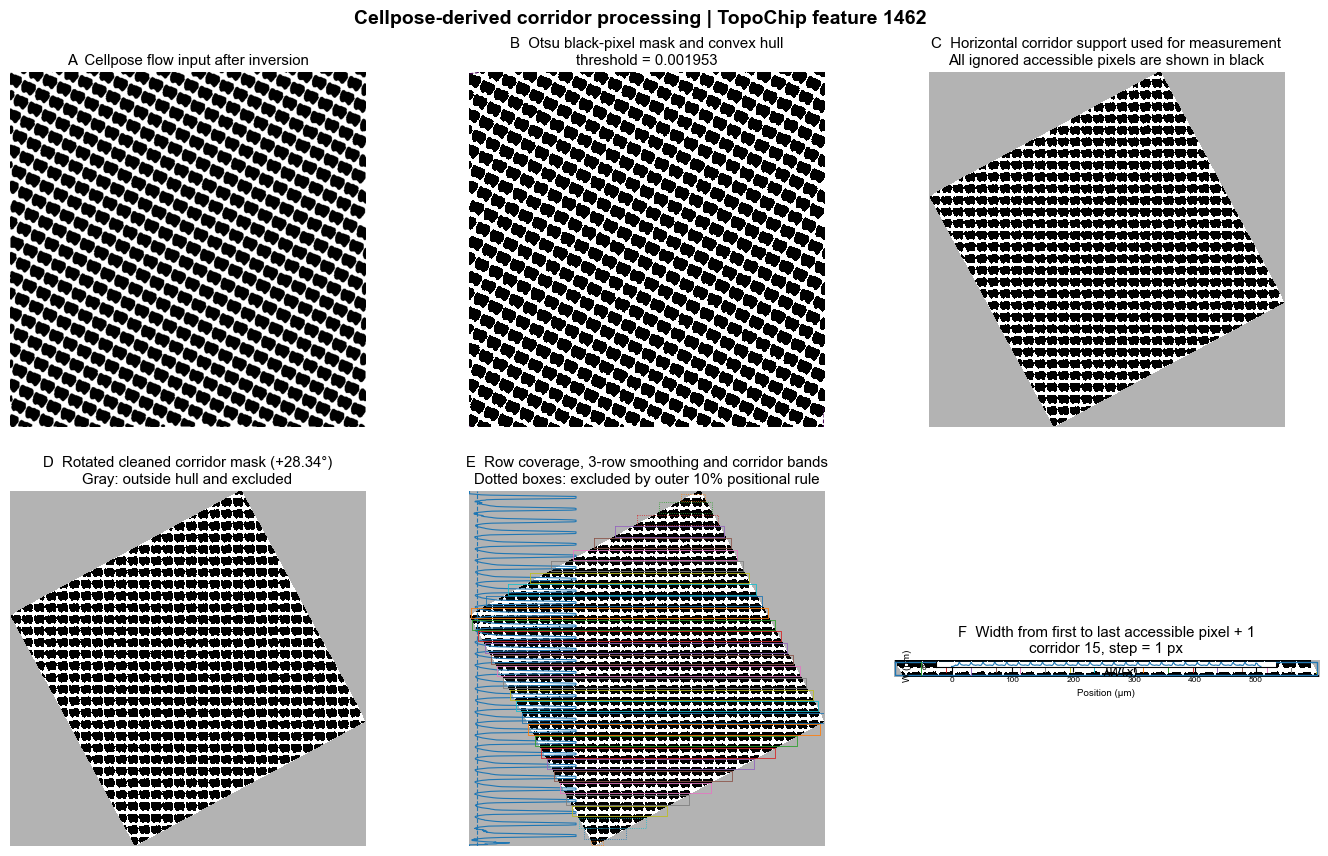

Detected bands: 31
Bands retained for width profiling after outer 10% rule: 25
Selected corridor: 15
Saved: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\cellpose_corridor_processing_1462_v4\cellpose_corridor_processing_schematic.png


In [4]:
result = process_cellpose_corridors(
    cellpose_image=CELLPOSE_IMAGE,
    reference_image=REFERENCE_IMAGE_FOR_RUN,
    invert_cellpose=INVERT_CELLPOSE,
    rotation_deg=ROTATION_DEG,
    row_cov_thresh_rel_hull=ROW_COVERAGE_THRESHOLD,
    tiny_white_px=MIN_ACCESSIBLE_COMPONENT_AREA,
    hole_area_threshold=MAX_FILLED_HOLE_AREA,
    merge_gap_px=MERGE_GAP_PX,
    min_band_height=MIN_BAND_HEIGHT,
    scan_step_px=SCAN_STEP_PX,
    pixel_size_um=PIXEL_SIZE_UM,
)

create_exact_processing_schematic(
    result=result,
    surface_name=SURFACE_NAME,
    output_dir=OUTPUT_DIR,
    selected_corridor_id=SELECTED_CORRIDOR_ID,
    save_pdf=SAVE_PDF,
)

In [5]:
display(result["corridors"])

print(f"All detected bands: {len(result['corridors'])}")
print(
    "Retained after outer 10% positional filter:",
    int(result["corridors"]["used_for_width_profile"].sum()),
)
print(
    "Figure:",
    (OUTPUT_DIR / "cellpose_corridor_processing_schematic.png").resolve(),
)

,corridor_id,x0,x1,y0,y1,height_px,used_for_width_profile
0,0,634,706,9,30,22,False
1,1,567,726,32,66,35,False
2,2,502,745,70,101,32,False
3,3,437,763,105,136,32,True
4,4,372,782,141,171,31,True
5,5,309,801,176,205,30,True
6,6,244,820,210,240,31,True
7,7,180,838,245,275,31,True
8,8,115,857,278,310,33,True
9,9,50,876,315,345,31,True


All detected bands: 31
Retained after outer 10% positional filter: 25
Figure: C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\cellpose_corridor_processing_1462_v4\cellpose_corridor_processing_schematic.png
